In [17]:
import os
import glob
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

In [18]:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'GPU: {len(gpus)} device(s)')

GPU: 1 device(s)


In [19]:
SOURCE_DIR    = 'audio_files'
AUGMENTED_DIR = 'augmented_audio'
CACHE_DIR     = 'feature_cache'
SAMPLE_RATE   = 22050
SAMPLES       = SAMPLE_RATE * 3
N_MELS        = 128
N_FFT         = 2048
HOP_LENGTH    = 512
EMOTION_NAMES = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

In [20]:
def fix_length(y):
    if len(y) > SAMPLES:
        return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad // 2, pad - pad // 2), 'constant')

def to_3ch(y, sr):
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([mel_db, librosa.feature.delta(mel_db), librosa.feature.delta(mel_db, order=2)], axis=-1)

def wav_to_feat(path):
    try:
        y, sr = librosa.load(path, sr=SAMPLE_RATE)
        return to_3ch(fix_length(y), sr)
    except:
        return None

In [21]:
CALM_NEUTRAL = {'02', '03'}
os.makedirs(AUGMENTED_DIR, exist_ok=True)

existing = glob.glob(os.path.join(AUGMENTED_DIR, '*.wav'))
if not existing:
    for fname in os.listdir(SOURCE_DIR):
        if not fname.endswith('.wav'):
            continue
        y, sr  = librosa.load(os.path.join(SOURCE_DIR, fname), sr=SAMPLE_RATE)
        parts  = fname.split('-')
        ecode  = parts[2] if len(parts) >= 3 else None
        base   = os.path.join(AUGMENTED_DIR, '{}' + fname)

        sf.write(base.format('orig_'),    y, sr)
        sf.write(base.format('noise_'),   y + 0.035*np.random.uniform()*np.amax(y)*np.random.normal(size=len(y)), sr)
        sf.write(base.format('strfast_'), fix_length(librosa.effects.time_stretch(y=y, rate=1.2)), sr)
        sf.write(base.format('pitch_'),   librosa.effects.pitch_shift(y=y, sr=sr, n_steps=0.7), sr)

        if ecode in CALM_NEUTRAL:
            sf.write(base.format('strslow_'), fix_length(librosa.effects.time_stretch(y=y, rate=0.85)), sr)
            sf.write(base.format('pup_'),     librosa.effects.pitch_shift(y=y, sr=sr, n_steps=1.5), sr)
            sf.write(base.format('pdn_'),     librosa.effects.pitch_shift(y=y, sr=sr, n_steps=-1.5), sr)
            n2 = y + 0.035*np.random.uniform()*np.amax(y)*np.random.normal(size=len(y))
            sf.write(base.format('noise2_'),  n2 + 0.035*np.random.uniform()*np.amax(n2)*np.random.normal(size=len(n2)), sr)
    print('Augmentation done')
else:
    print(f'Skipped — {len(existing)} augmented files already exist')

Skipped — 9888 augmented files already exist


In [ ]:
os.makedirs(CACHE_DIR, exist_ok=True)

cache_X_path = os.path.join(CACHE_DIR, 'X.npy')
cache_y_path = os.path.join(CACHE_DIR, 'y.npy')
cache_src_path = os.path.join(CACHE_DIR, 'sources.npy')

if os.path.exists(cache_X_path):
    X_all     = np.load(cache_X_path)
    y_all     = np.load(cache_y_path)
    sources   = np.load(cache_src_path)  
    print(f'Loaded from cache: {X_all.shape}')
else:
    feats, labs, srcs = [], [], []
    all_wavs = sorted(glob.glob(os.path.join(AUGMENTED_DIR, '*.wav')))
    for i, path in enumerate(all_wavs):
        fname = os.path.basename(path)
        stem  = fname.split('_', 1)[-1] if '_' in fname else fname
        parts = stem.replace('.wav','').split('-')
        if len(parts) < 3:
            continue
        try:
            ecode = int(parts[2]) - 1
        except ValueError:
            continue
        feat = wav_to_feat(path)
        if feat is not None:
            feats.append(feat)
            labs.append(ecode)
            srcs.append(stem)            
        if i % 200 == 0:
            print(f'  {i}/{len(all_wavs)} processed...')

    X_all   = np.array(feats,  dtype=np.float32)
    y_all   = np.array(labs,   dtype=np.int32)
    sources = np.array(srcs)
    np.save(cache_X_path,   X_all)
    np.save(cache_y_path,   y_all)
    np.save(cache_src_path, sources)
    print(f'Cached: {X_all.shape}')

Loaded from cache: (9888, 128, 130, 3)


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

def focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        weight = y_true * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn

def build_model(input_shape):
    m = Sequential([
        Conv2D(32,  (3,3), activation='relu', input_shape=input_shape, padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(64,  (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.3),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(8, activation='softmax')
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=focal_loss(gamma=2.0),
        metrics=['accuracy']
    )
    return m

In [24]:
BATCH_SIZE = 32

def make_dataset(X, y_cat, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y_cat))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

unique_sources = np.unique(sources)
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_src_idx, va_src_idx) in enumerate(kfold.split(unique_sources)):
    print(f"── Fold {fold+1}/3 ──")

    tr_sources    = set(unique_sources[tr_src_idx])
    va_sources    = set(unique_sources[va_src_idx])
    tr_mask       = np.array([s in tr_sources for s in sources])
    va_mask       = np.array([s in va_sources for s in sources])
    tr_mask_final = tr_mask & ~va_mask

    X_tr = X_all[tr_mask_final].astype(np.float32)
    y_tr = y_all[tr_mask_final]
    X_va = X_all[va_mask].astype(np.float32)
    y_va = y_all[va_mask]

    y_tr_cat = to_categorical(y_tr, num_classes=8)
    y_va_cat = to_categorical(y_va, num_classes=8)
    cw       = compute_class_weight("balanced", classes=np.arange(8), y=y_tr)

    train_ds = make_dataset(X_tr, y_tr_cat, shuffle=True)
    val_ds   = make_dataset(X_va, y_va_cat)

    tf.keras.backend.clear_session()
    model = build_model(X_tr.shape[1:])

    callbacks = [
        ReduceLROnPlateau(monitor="val_accuracy", patience=5, factor=0.5, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True)
    ]

    model.fit(
        train_ds,
        epochs=100,
        validation_data=val_ds,
        class_weight=dict(enumerate(cw)),
        callbacks=callbacks,
        verbose=1
    )

    y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)
    acc    = np.mean(y_pred == y_va)

    fold_results.append({"fold": fold+1, "model": model,
                         "acc": acc, "y_pred": y_pred, "y_true": y_va})
    print(f"Fold {fold+1} acc: {acc:.4f}  (train: {len(y_tr)}, val: {len(y_va)})")

accs = [r["acc"] for r in fold_results]
best = max(fold_results, key=lambda x: x["acc"])
model = best["model"]
print(f"Mean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}  Best fold: {best['fold']}")


── Fold 1/3 ──
Epoch 1/100
205/205 [==============================] - 17s 36ms/step - loss: 1.4509 - accuracy: 0.3779 - val_loss: 3.3018 - val_accuracy: 0.0933 - lr: 0.0010
Epoch 2/100
205/205 [==============================] - 7s 32ms/step - loss: 1.0982 - accuracy: 0.4983 - val_loss: 1.3240 - val_accuracy: 0.3828 - lr: 0.0010
Epoch 3/100
205/205 [==============================] - 7s 32ms/step - loss: 0.9568 - accuracy: 0.5504 - val_loss: 1.3522 - val_accuracy: 0.3269 - lr: 0.0010
Epoch 4/100
205/205 [==============================] - 7s 32ms/step - loss: 0.8663 - accuracy: 0.5851 - val_loss: 1.2096 - val_accuracy: 0.4794 - lr: 0.0010
Epoch 5/100
205/205 [==============================] - 7s 32ms/step - loss: 0.7848 - accuracy: 0.6209 - val_loss: 0.8151 - val_accuracy: 0.6103 - lr: 0.0010
Epoch 6/100
205/205 [==============================] - 7s 32ms/step - loss: 0.7039 - accuracy: 0.6656 - val_loss: 1.2086 - val_accuracy: 0.4877 - lr: 0.0010
Epoch 7/100
205/205 [=====================

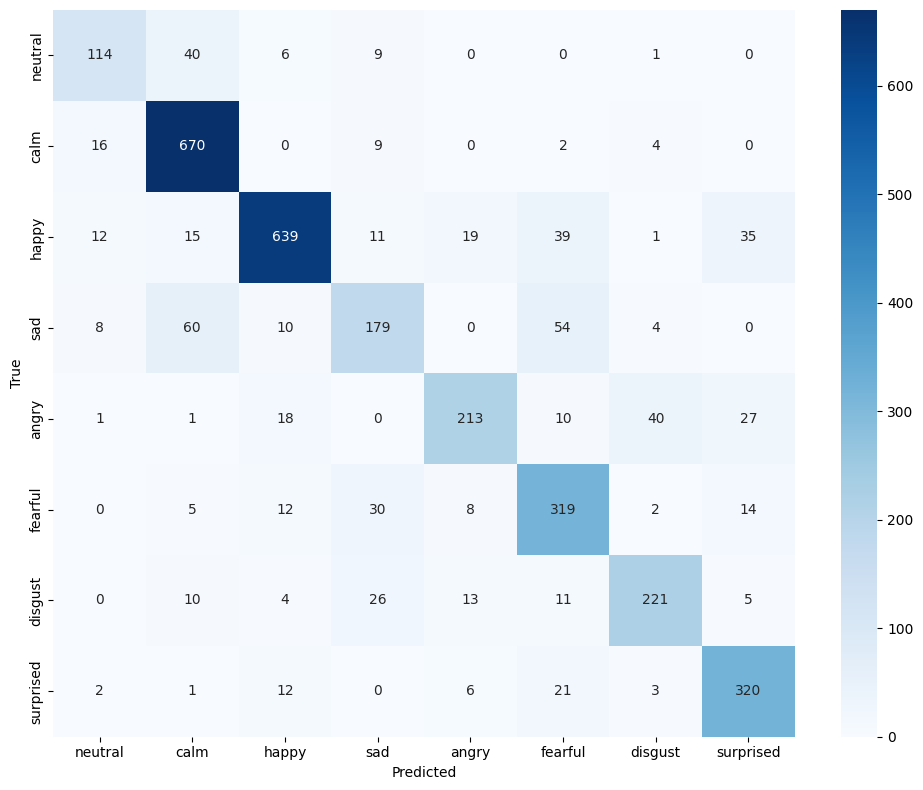

              precision    recall  f1-score   support

     neutral       0.75      0.67      0.71       170
        calm       0.84      0.96      0.89       701
       happy       0.91      0.83      0.87       771
         sad       0.68      0.57      0.62       315
       angry       0.82      0.69      0.75       310
     fearful       0.70      0.82      0.75       390
     disgust       0.80      0.76      0.78       290
   surprised       0.80      0.88      0.84       365

    accuracy                           0.81      3312
   macro avg       0.79      0.77      0.78      3312
weighted avg       0.81      0.81      0.81      3312



In [25]:
cm = confusion_matrix(best['y_true'], best['y_pred'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()
print(classification_report(best['y_true'], best['y_pred'], target_names=EMOTION_NAMES))

In [26]:
model.save('best_emotion_model.h5')

In [28]:
# def predict_emotion(file_path):
#     y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
#     spec  = to_3ch(fix_length(y), sr)[np.newaxis, ...]
#     pred  = model.predict(spec, verbose=0)
#     idx   = np.argmax(pred)
#     return EMOTION_NAMES[idx], float(np.max(pred)) * 100

# emotion, conf = predict_emotion('test_voice.wav')
# print(f'{emotion.upper()} — {conf:.1f}%')